# Histogram Modeling — Progress Update

Figures for the `try6_hist_pow-xf_22km` product.  
Model: **HistogramMLP** (3-layer MLP, KL-div loss, 5-fold CV).  
Baseline: **Mean histogram** (per-trait average over training set).

In [8]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path("../..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

RUN_DIR = PROJECT_ROOT / "models/try6_hist_pow-xf_22km/training/run_20260227_155511"
CV_DIR = RUN_DIR / "cv"
HPO_DIR = PROJECT_ROOT / "models/try6_hist_pow-xf_22km/hpo/hpo_20260227_120238"
ZARR_PATH = PROJECT_ROOT / "data/features/try6_hist_pow-xf_22km/xy_data/train.zarr"

# Load metrics
with open(CV_DIR / "cv_summary.json") as f:
    cv = json.load(f)
perf = pd.read_csv(CV_DIR / "performance_summary.csv")

# Dark slide theme
sns.set_theme(style="dark", rc={
    "figure.dpi": 300,
    "figure.facecolor": "black",
    "axes.facecolor": "black",
    "savefig.facecolor": "black",
    "savefig.dpi": 300,
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "axes.titlecolor": "white",
    "axes.edgecolor": "#444444",
    "grid.color": "#333333",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.facecolor": "#1a1a1a",
    "legend.edgecolor": "#555555",
    "legend.labelcolor": "white",
})

# Two-color palette: cyan for model, magenta/pink for baseline
C_MODEL = "#00e5ff"   # bright cyan
C_BASE = "#ff4081"    # bright pink/magenta
C_ACCENT = "#76ff03"  # lime green for annotations/highlights
C_LINE = "#888888"    # muted gray for connectors

print(f"Loaded {len(perf)} traits, {cv['n_folds']} folds")

Loaded 31 traits, 5 folds


## Figure 1: Model vs. Baseline — Overall Metrics Summary

Grouped bar chart comparing model and baseline across 4 distribution metrics (averaged over 31 traits, 5-fold CV).

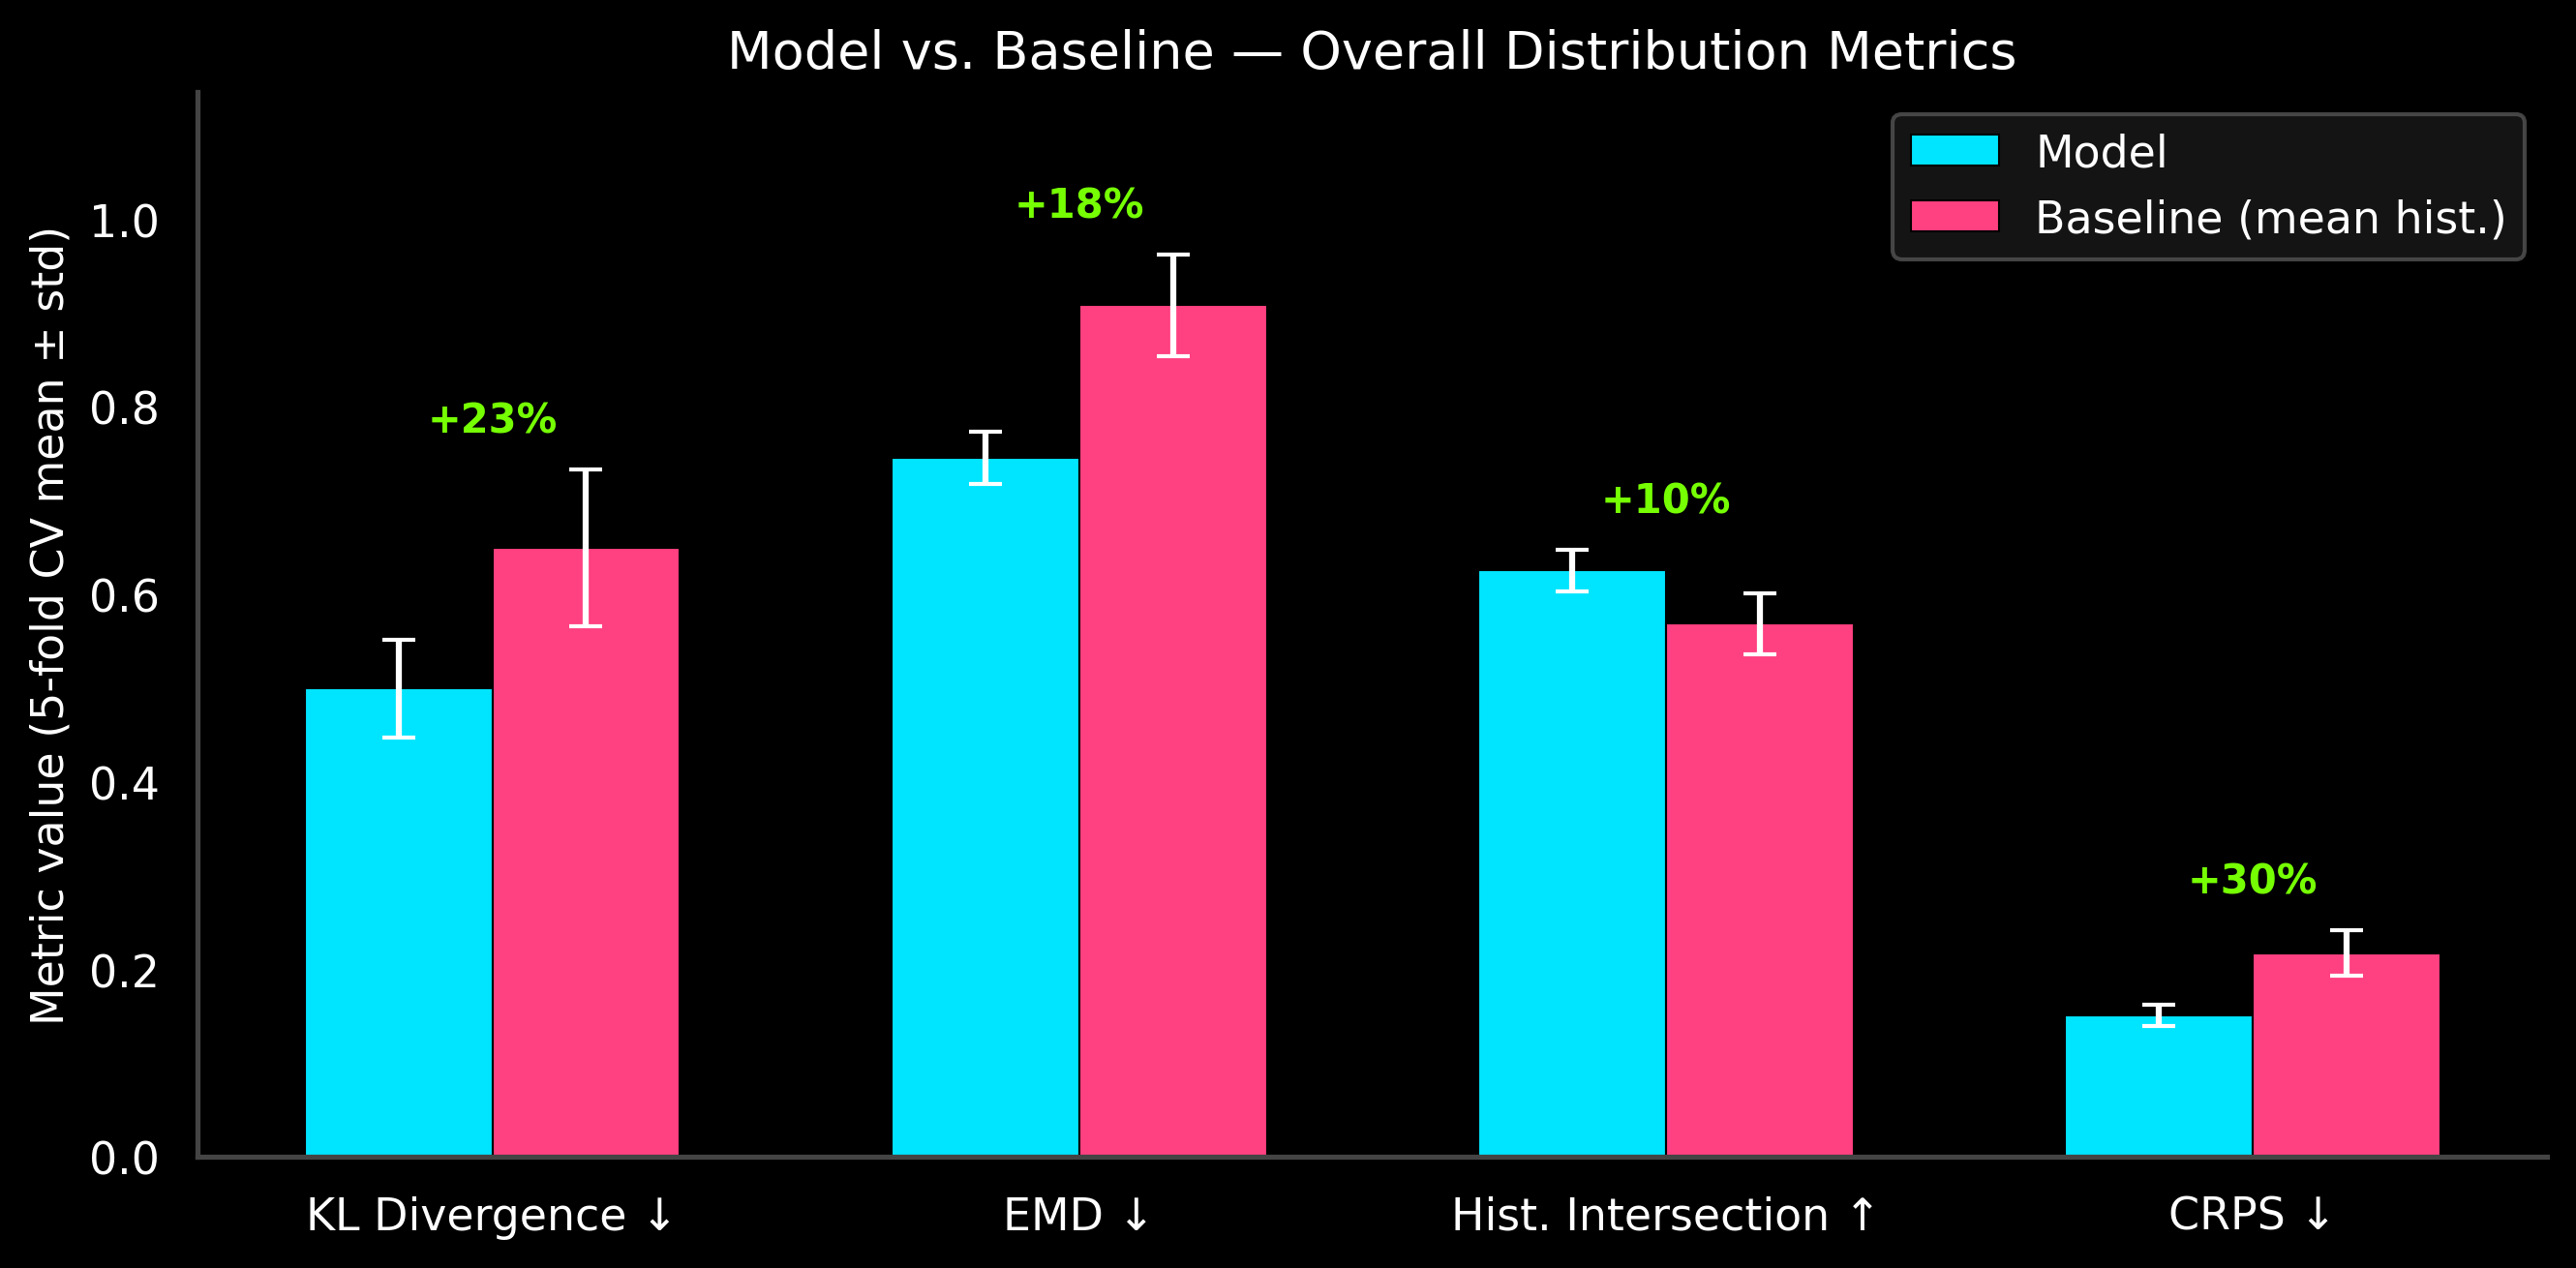

In [9]:
metrics = ["KL Divergence ↓", "EMD ↓", "Hist. Intersection ↑", "CRPS ↓"]
model_vals = [cv["kl_divergence_mean"], cv["emd_mean"], cv["histogram_intersection_mean"], cv["crps_mean"]]
model_stds = [cv["kl_divergence_std"], cv["emd_std"], cv["histogram_intersection_std"], cv["crps_std"]]
base_vals = [cv["baseline_kl_divergence_mean"], cv["baseline_emd_mean"],
             cv["baseline_histogram_intersection_mean"], cv["baseline_crps_mean"]]
base_stds = [cv["baseline_kl_divergence_std"], cv["baseline_emd_std"],
             cv["baseline_histogram_intersection_std"], cv["baseline_crps_std"]]

# Compute relative improvement
improvements = []
for i, m in enumerate(metrics):
    if "↑" in m:
        pct = (model_vals[i] - base_vals[i]) / base_vals[i] * 100
    else:
        pct = (base_vals[i] - model_vals[i]) / base_vals[i] * 100
    improvements.append(pct)

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(metrics))
w = 0.32

bars_m = ax.bar(x - w / 2, model_vals, w, yerr=model_stds, label="Model", color=C_MODEL,
                capsize=4, edgecolor="black", linewidth=0.5, error_kw=dict(ecolor="white", capthick=1))
bars_b = ax.bar(x + w / 2, base_vals, w, yerr=base_stds, label="Baseline (mean hist.)", color=C_BASE,
                capsize=4, edgecolor="black", linewidth=0.5, error_kw=dict(ecolor="white", capthick=1))

# Annotate improvement
for i, pct in enumerate(improvements):
    y_top = max(model_vals[i] + model_stds[i], base_vals[i] + base_stds[i]) + 0.03
    sign = "+" if pct > 0 else ""
    ax.text(x[i], y_top, f"{sign}{pct:.0f}%", ha="center", va="bottom", fontsize=10, fontweight="bold",
            color=C_ACCENT)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Metric value (5-fold CV mean ± std)")
ax.set_title("Model vs. Baseline — Overall Distribution Metrics")
ax.legend(loc="upper right")
ax.set_ylim(0, max(max(model_vals), max(base_vals)) * 1.25)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## Figure 2: Per-Trait R² — Model vs. Baseline (Lollipop Plot)

Horizontal lollipop chart showing model R² (blue) vs. baseline R² (orange) for all 31 traits, sorted by improvement (Δ R²). The model achieves positive R² on all traits; the mean-histogram baseline is negative everywhere.

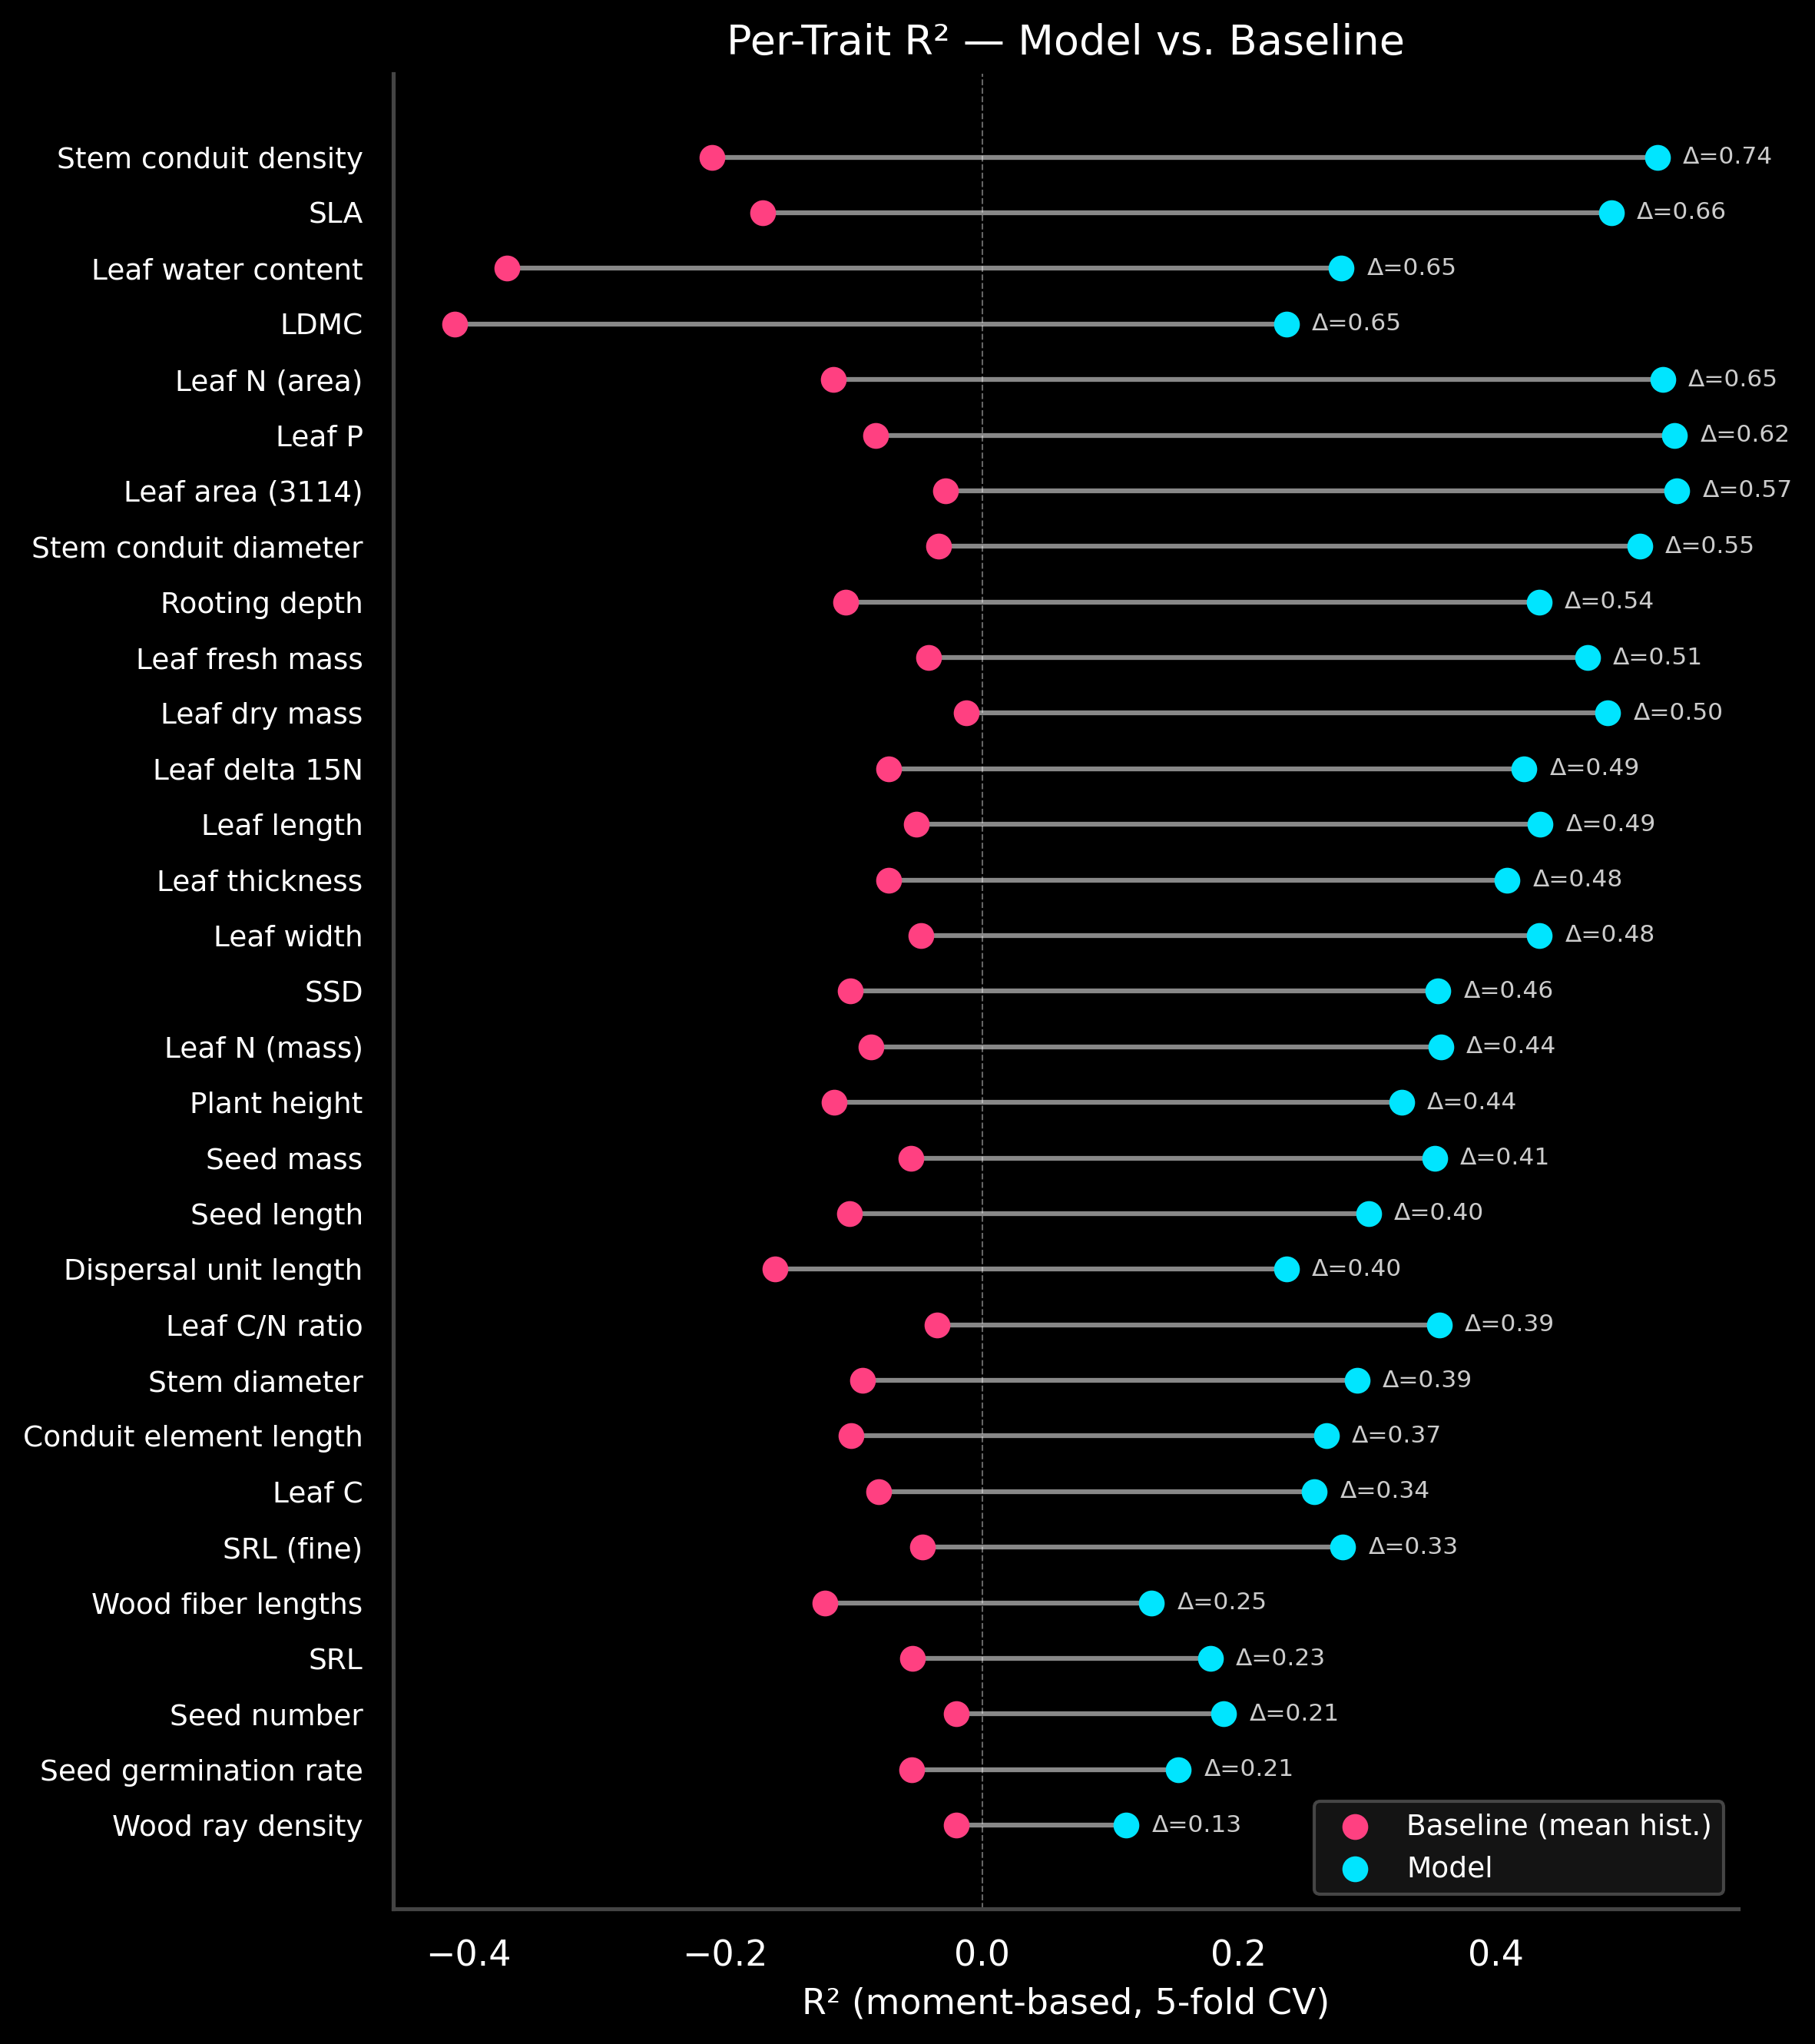

In [10]:
df = perf.sort_values("delta_R2", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 9))
y = np.arange(len(df))

# Draw connecting lines
for i, row in df.iterrows():
    ax.plot([row["baseline_R2"], row["model_R2"]], [i, i], color=C_LINE, linewidth=1.5, zorder=1)

ax.scatter(df["baseline_R2"], y, color=C_BASE, s=50, zorder=2, label="Baseline (mean hist.)")
ax.scatter(df["model_R2"], y, color=C_MODEL, s=50, zorder=2, label="Model")

# Annotate delta R² on the right
for i, row in df.iterrows():
    ax.text(row["model_R2"] + 0.02, i, f"Δ={row['delta_R2']:.2f}", va="center", fontsize=7.5, color="#cccccc")

ax.axvline(0, color="white", linewidth=0.5, linestyle="--", alpha=0.4)
ax.set_yticks(y)
ax.set_yticklabels(df["short_name"], fontsize=9)
ax.set_xlabel("R² (moment-based, 5-fold CV)")
ax.set_title("Per-Trait R² — Model vs. Baseline")
ax.legend(loc="lower right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

## Figure 3: Example Predicted Histograms vs. Targets

2×3 panel of predicted (blue) vs. target (orange) histograms for selected validation cells across well-predicted traits. Uses fold 0 validation set.

In [11]:
import torch
import zarr
from models.histogram_mlp.model import HistogramMLP

# Load data
root = zarr.open_group(str(ZARR_PATH), mode="r")
X_raw = np.asarray(root["X"])
Y_hist = np.asarray(root["Y_hist"])
Y_mask = np.asarray(root["Y_mask"])
source = np.asarray(root["source"])
folds = np.asarray(root["folds"])
bin_edges = np.asarray(root["bin_edges"])
trait_names = list(root.attrs.get("trait_names", []))

# Load feature stats for preprocessing
stats = np.load(RUN_DIR / "feature_stats.npz")

# Preprocess features using saved stats
X = X_raw.copy().astype(np.float32)
X[X == 32767.0] = np.nan
X[X == -32767.0] = np.nan
for j in range(X.shape[1]):
    X[np.isnan(X[:, j]), j] = stats["median"][j]
X = (X - stats["mean"]) / stats["std"]

# Fold 0 val indices: sPlot cells (source==1) in fold 0
val_mask = (folds == 0) & (source == 1)
val_idx = np.where(val_mask)[0]

# Load fold 0 model
model = HistogramMLP(n_features=X.shape[1], n_traits=len(trait_names), n_bins=20,
                     hidden_dims=[1024, 768, 1024], dropout=0.35)
model.load_state_dict(torch.load(CV_DIR / "fold_0/best_model.pt", map_location="cpu", weights_only=True))
model.eval()

# Predict on validation set
with torch.no_grad():
    X_val = torch.from_numpy(X[val_idx]).float()
    log_pred = model(X_val)
    pred_probs = torch.exp(log_pred).numpy()  # (N_val, 31, 20)

print(f"Validation cells: {len(val_idx)}, predictions: {pred_probs.shape}")

Validation cells: 4554, predictions: (4554, 31, 20)


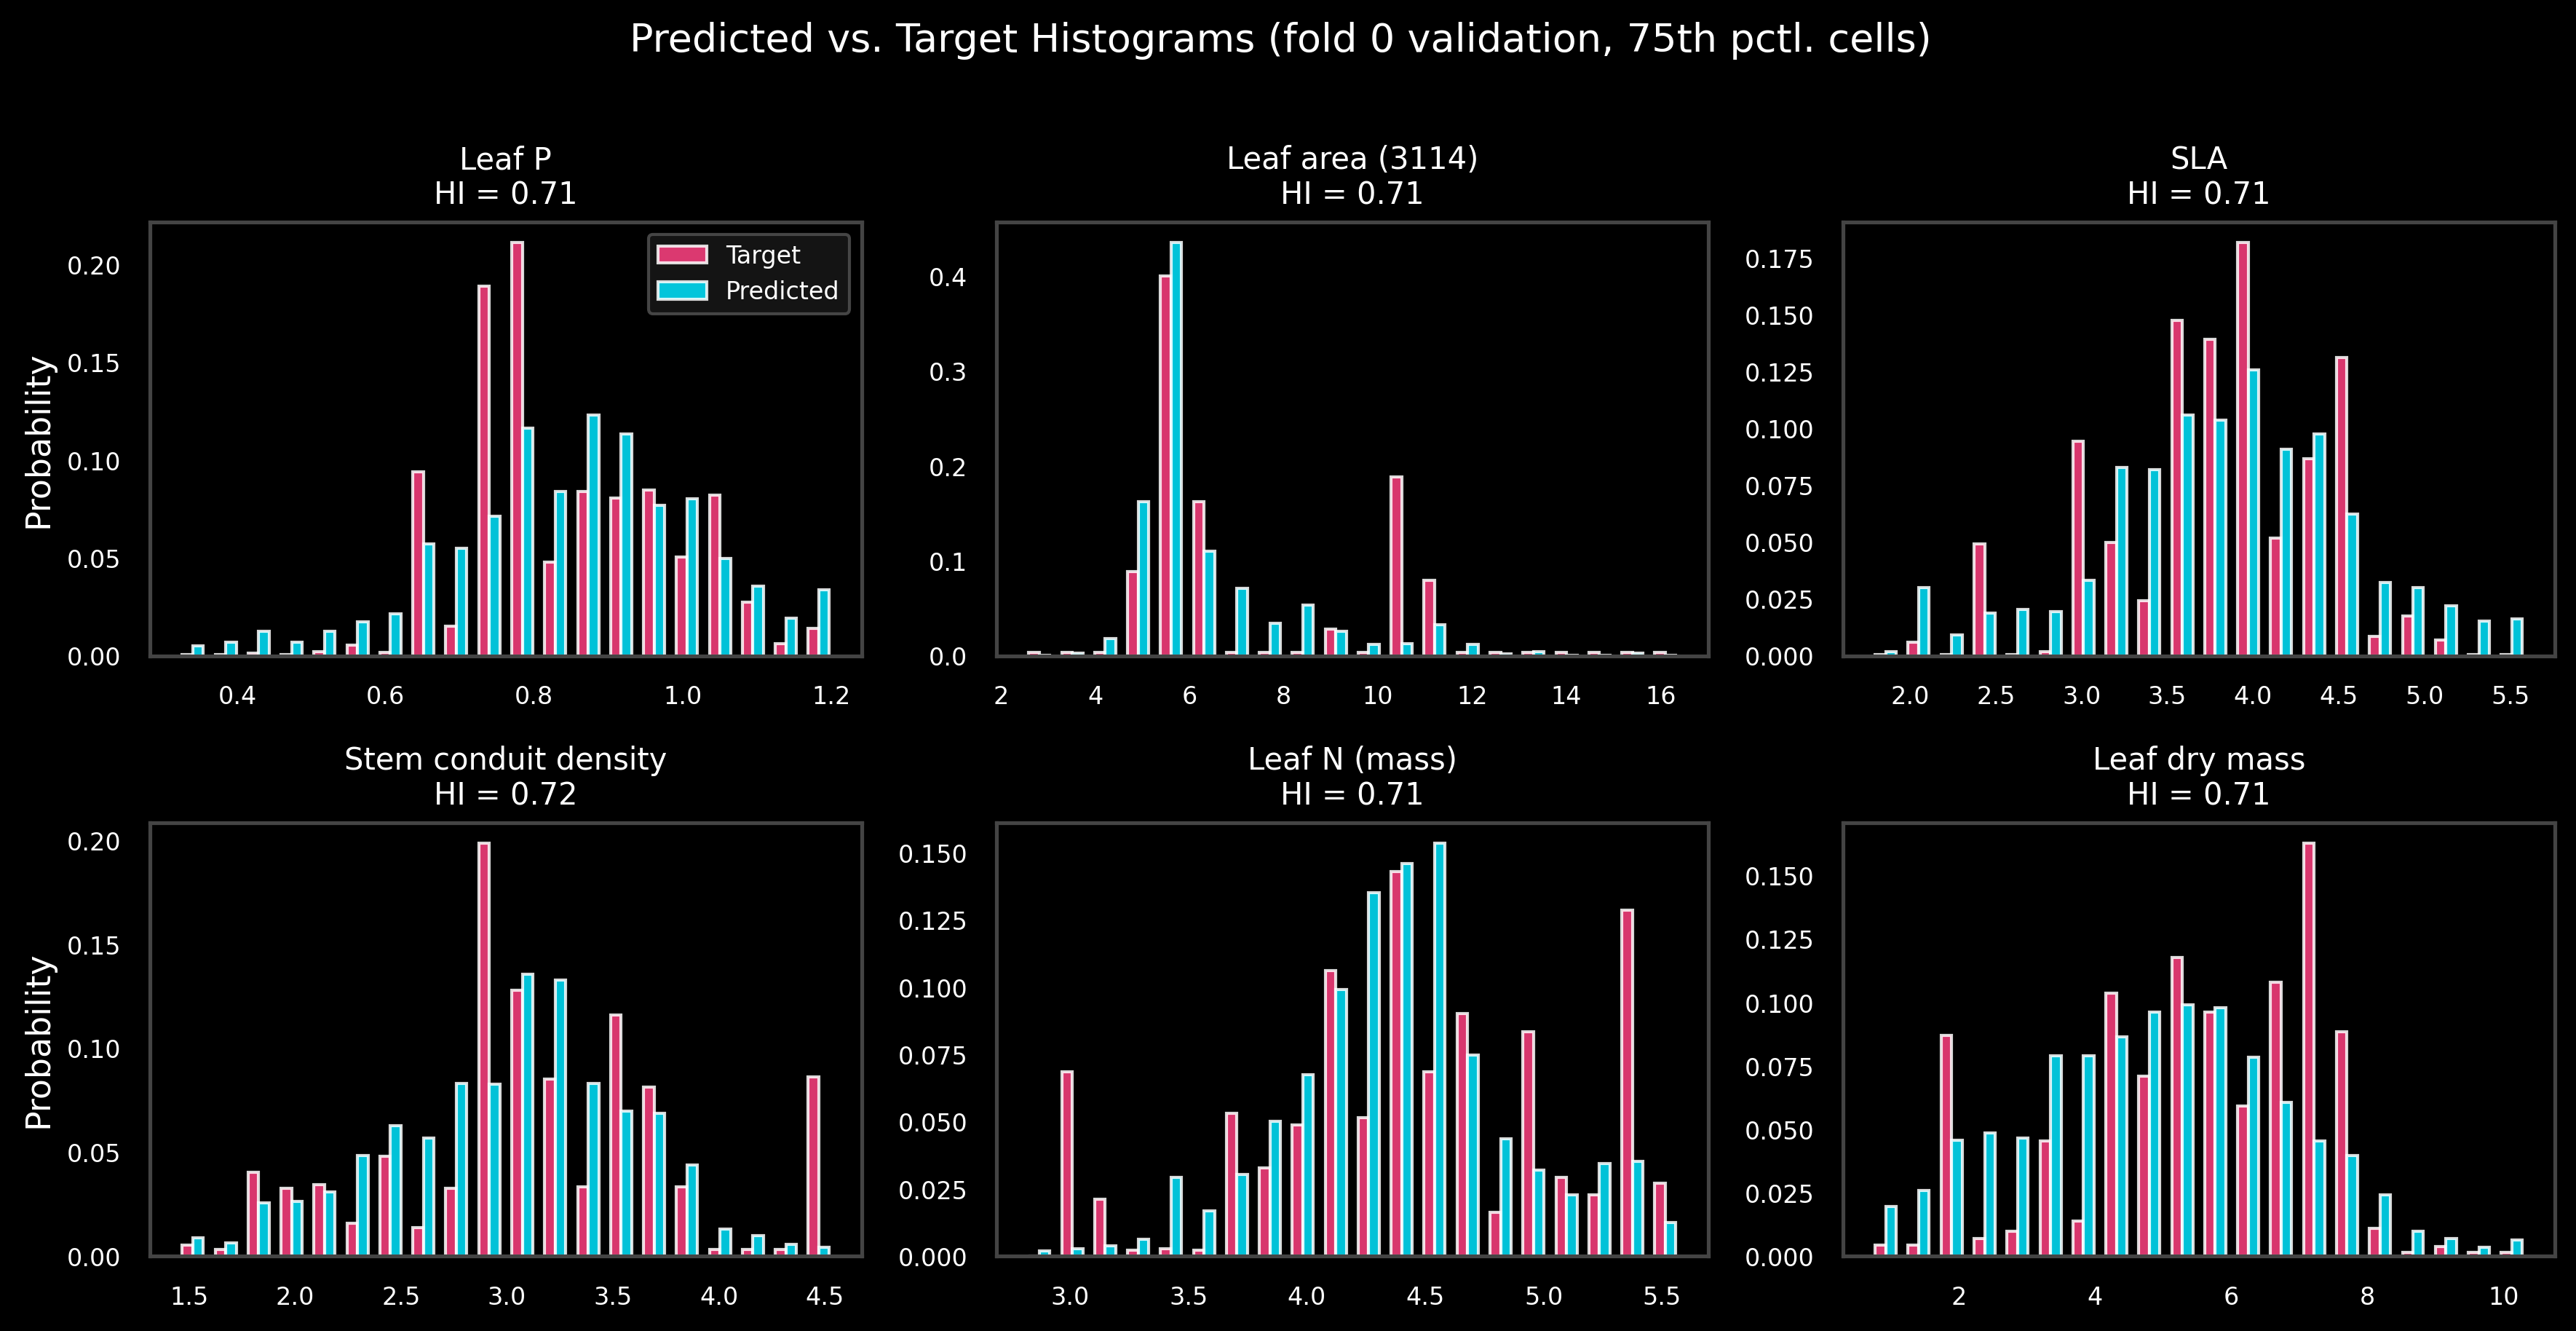

In [ ]:
# Select 6 well-predicted traits and pick representative cells
show_traits = ["Leaf P", "Leaf area (3114)", "SLA", "Stem conduit density", "Leaf N (mass)", "Leaf dry mass"]
trait_id_map = dict(zip(perf["short_name"], perf["trait_id"]))

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

for ax, trait_name in zip(axes.flat, show_traits):
    tid = trait_id_map[trait_name]
    t_idx = trait_names.index(tid)

    # Find cells with valid data for this trait
    valid = Y_mask[val_idx, t_idx] > 0
    valid_pos = np.where(valid)[0]

    # Pick cell with best histogram intersection for a visually compelling example
    hi_scores = []
    for vi in valid_pos:
        pred = pred_probs[vi, t_idx]
        target = Y_hist[val_idx[vi], t_idx]
        hi_scores.append(np.sum(np.minimum(pred, target)))
    # Pick the cell near the 75th percentile (good but not cherry-picked)
    rank_idx = valid_pos[np.argsort(hi_scores)[int(len(hi_scores) * 0.75)]]

    pred = pred_probs[rank_idx, t_idx]
    target = Y_hist[val_idx[rank_idx], t_idx]
    edges = bin_edges[t_idx]
    centers = 0.5 * (edges[:-1] + edges[1:])
    width = (edges[1] - edges[0]) * 0.8

    ax.bar(centers - width * 0.2, target, width * 0.4, label="Target", color=C_BASE, alpha=0.85)
    ax.bar(centers + width * 0.2, pred, width * 0.4, label="Predicted", color=C_MODEL, alpha=0.85)
    hi = np.sum(np.minimum(pred, target))
    ax.set_title(f"{trait_name}\nHI = {hi:.3f}", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(labelsize=8)

axes[0, 0].set_ylabel("Probability")
axes[1, 0].set_ylabel("Probability")
axes[0, 0].legend(fontsize=8, loc="upper right")
fig.suptitle("Predicted vs. Target Histograms (fold 0 validation, 75th pctl. cells)", fontsize=13, y=1.01, color="white")
fig.tight_layout()
plt.show()

## Figure 4: HPO Convergence

Scatter plot of validation loss across Optuna trials, showing convergence toward the best trial. Colored by batch size to highlight which search regions worked best.

/tmp/ipykernel_3043678/4220111432.py:4: FutureWarning: JournalFileStorage has been deprecated in v4.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.0.0. Use :class:`~optuna.storages.journal.JournalFileBackend` instead.
  storage = JournalStorage(JournalFileStorage(str(HPO_DIR / "journal.log")))


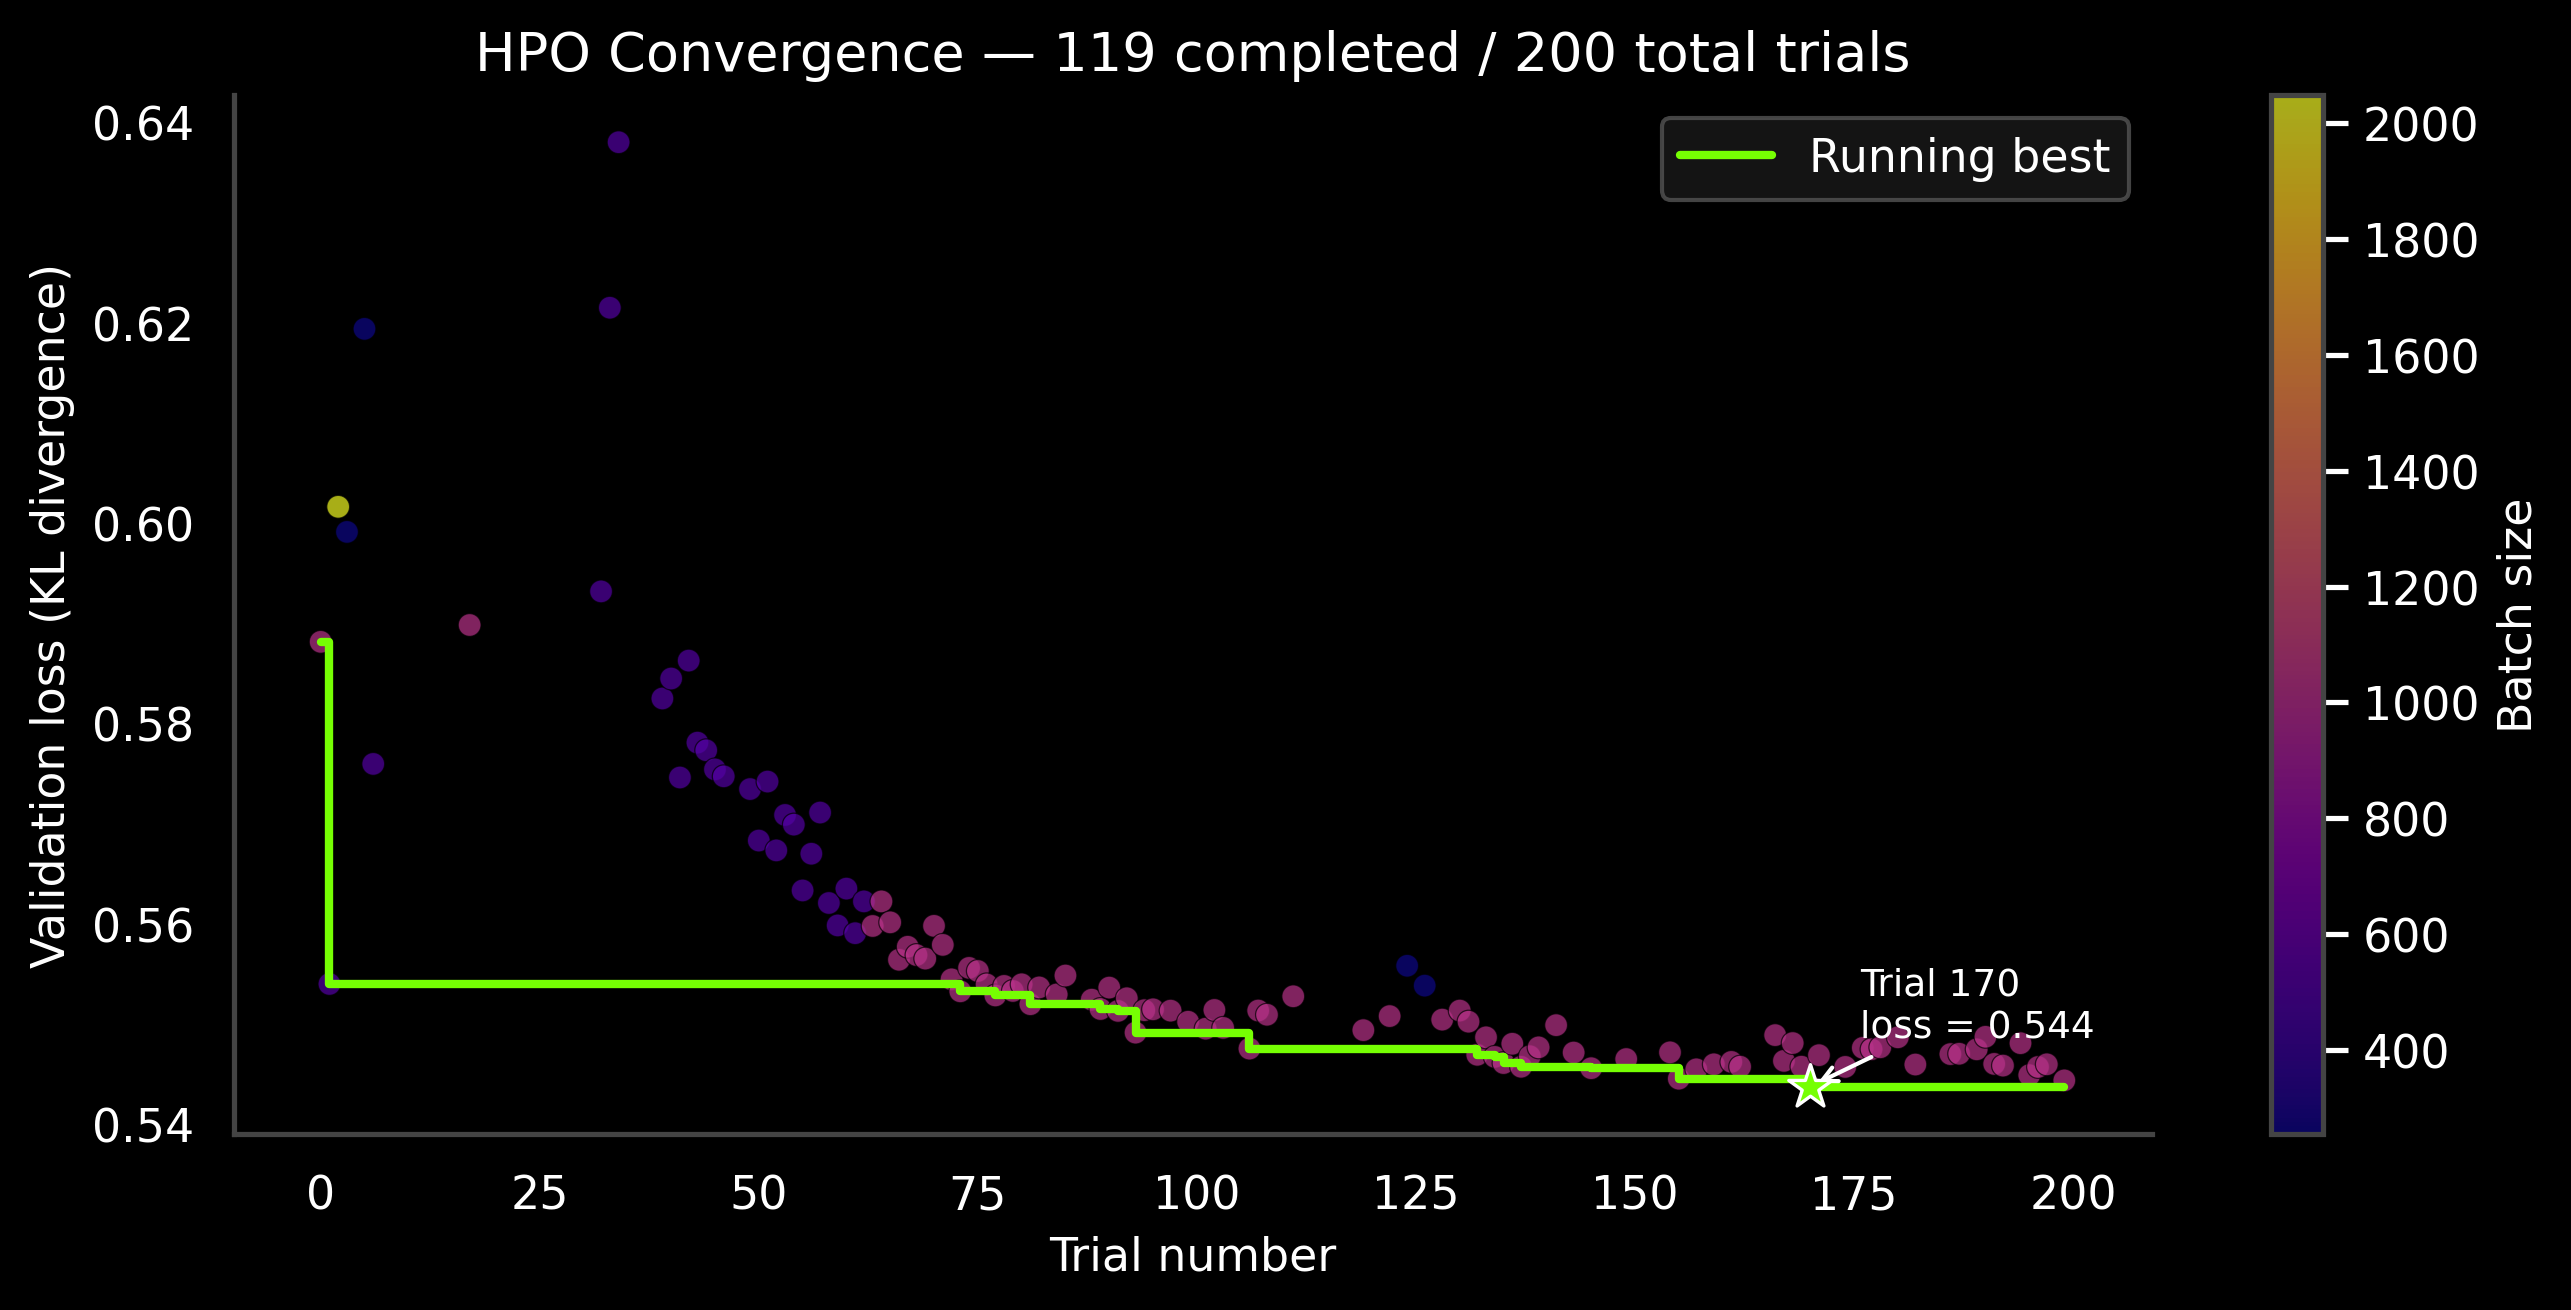

Hyperparameter,Value
Hidden layers,3
Hidden dim 1,1024
Hidden dim 2,768
Hidden dim 3,1024
Dropout,0.3500
Learning rate,5.13e-04
Weight decay,1.73e-05
Batch size,1024
GBIF weight factor,0.5039
Best val loss,0.5437


In [13]:
import optuna
from optuna.storages import JournalStorage, JournalFileStorage

storage = JournalStorage(JournalFileStorage(str(HPO_DIR / "journal.log")))
study = optuna.load_study(study_name="hpo_20260227_120238", storage=storage)

# Extract completed trials
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
trial_nums = [t.number for t in completed]
val_losses = [t.value for t in completed]
batch_sizes = [t.params.get("batch_size", np.nan) for t in completed]

# Running best
sorted_trials = sorted(zip(trial_nums, val_losses), key=lambda x: x[0])
running_best = []
best_so_far = float("inf")
for tn, vl in sorted_trials:
    best_so_far = min(best_so_far, vl)
    running_best.append((tn, best_so_far))

fig, ax = plt.subplots(figsize=(9, 4.5))
sc = ax.scatter(trial_nums, val_losses, c=batch_sizes, cmap="plasma", s=30, alpha=0.7,
                edgecolors="black", linewidth=0.3)
rb_x, rb_y = zip(*running_best)
ax.step(rb_x, rb_y, color=C_ACCENT, linewidth=2, label="Running best", where="post")

# Mark best trial
best = study.best_trial
ax.scatter([best.number], [best.value], color=C_ACCENT, s=120, zorder=5, marker="*",
           edgecolors="white", linewidth=0.8)
ax.annotate(f"Trial {best.number}\nloss = {best.value:.3f}", (best.number, best.value),
            textcoords="offset points", xytext=(12, 12), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="white"), color="white")

cbar = fig.colorbar(sc, ax=ax, label="Batch size")
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")
cbar.ax.yaxis.label.set_color("white")

ax.set_xlabel("Trial number")
ax.set_ylabel("Validation loss (KL divergence)")
ax.set_title(f"HPO Convergence — {len(completed)} completed / {len(study.trials)} total trials")
ax.legend(loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

# Best hyperparameters as a copy-pasteable table
from IPython.display import display

param_labels = {
    "n_layers": "Hidden layers",
    "hidden_dim_0": "Hidden dim 1",
    "hidden_dim_1": "Hidden dim 2",
    "hidden_dim_2": "Hidden dim 3",
    "dropout": "Dropout",
    "lr": "Learning rate",
    "weight_decay": "Weight decay",
    "batch_size": "Batch size",
    "gbif_weight_factor": "GBIF weight factor",
}

rows = []
for k, v in best.params.items():
    label = param_labels.get(k, k)
    if isinstance(v, float):
        formatted = f"{v:.2e}" if v < 0.001 else f"{v:.4f}"
    else:
        formatted = str(v)
    rows.append({"Hyperparameter": label, "Value": formatted})
rows.append({"Hyperparameter": "Best val loss", "Value": f"{best.value:.4f}"})
rows.append({"Hyperparameter": "Trial number", "Value": str(best.number)})

hp_df = pd.DataFrame(rows)
display(hp_df.style.hide(axis="index").set_properties(**{
    "text-align": "left",
    "font-size": "13px",
}))

## Figure 5: Pipeline / Method Diagram

Schematic overview of the histogram modeling approach.

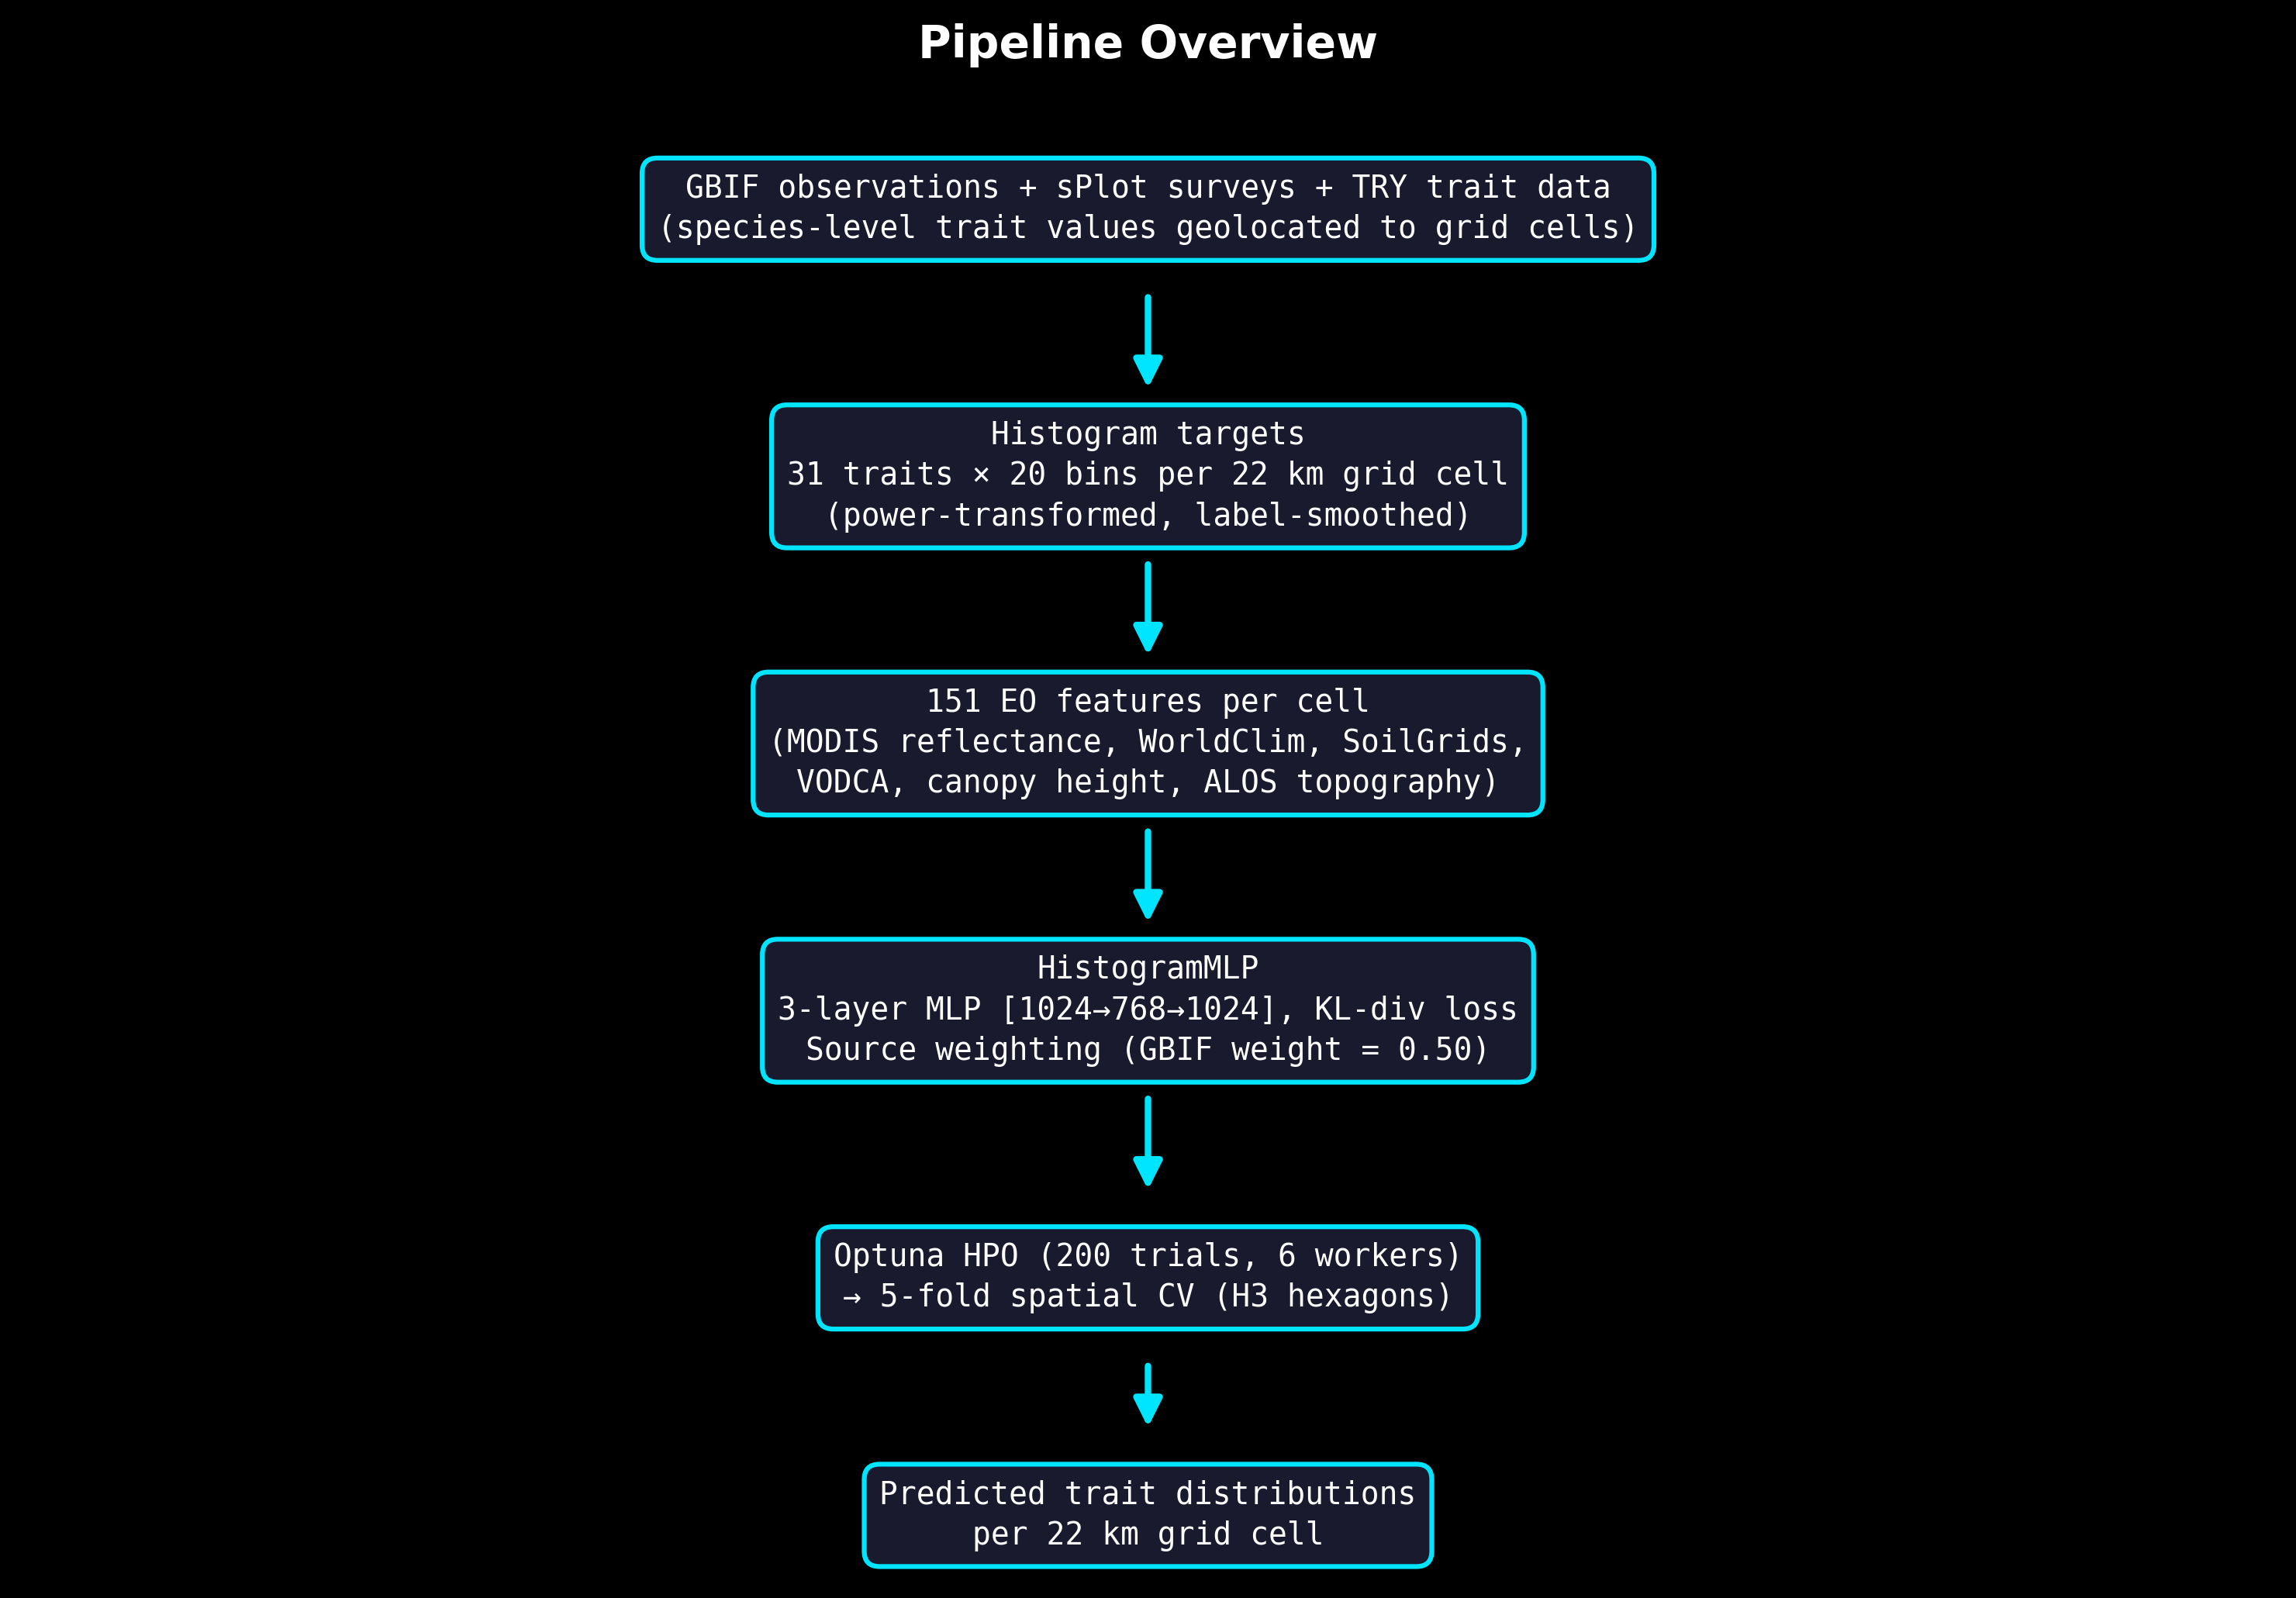

In [14]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

box_style = dict(boxstyle="round,pad=0.5", facecolor="#1a1a2e", edgecolor=C_MODEL, linewidth=1.5)
arrow_kw = dict(arrowstyle="-|>", color=C_MODEL, linewidth=2, mutation_scale=18)

boxes = [
    (5, 9.2, "GBIF observations + sPlot surveys + TRY trait data\n(species-level trait values geolocated to grid cells)"),
    (5, 7.4, "Histogram targets\n31 traits × 20 bins per 22 km grid cell\n(power-transformed, label-smoothed)"),
    (5, 5.6, "151 EO features per cell\n(MODIS reflectance, WorldClim, SoilGrids,\nVODCA, canopy height, ALOS topography)"),
    (5, 3.8, "HistogramMLP\n3-layer MLP [1024→768→1024], KL-div loss\nSource weighting (GBIF weight = 0.50)"),
    (5, 2.0, "Optuna HPO (200 trials, 6 workers)\n→ 5-fold spatial CV (H3 hexagons)"),
    (5, 0.4, "Predicted trait distributions\nper 22 km grid cell"),
]

for x, y, text in boxes:
    ax.text(x, y, text, ha="center", va="center", fontsize=9.5, bbox=box_style,
            fontfamily="monospace", linespacing=1.4, color="white")

for i in range(len(boxes) - 1):
    ax.annotate("", xy=(5, boxes[i + 1][1] + 0.55), xytext=(5, boxes[i][1] - 0.55),
                arrowprops=arrow_kw)

ax.set_title("Pipeline Overview", fontsize=14, fontweight="bold", pad=10, color="white")
fig.tight_layout()
plt.show()